# Baseline: Árvore de Decisão

> Objetivo: treinar um modelo simples de árvore de decisão e avaliar desempenho no conjunto de teste.

> Referência: conteúdo copiado e adaptado de Modelação.ipynb.

## 1) Importação e leitura dos dados

In [2]:
# importações de bibliotecas
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 2) Preparação dos dados

In [3]:
# Converter variáveis categóricas e definir X/y
ortho_clean['Grupo_pre'] = ortho_clean['Grupo_pre'].astype('category')
ortho_clean['Sexo'] = ortho_clean['Sexo'].astype('category')

X = ortho_clean.drop('mudanca_CPAK', axis=1)
y = ortho_clean['mudanca_CPAK']

X_ohe = pd.get_dummies(X, columns=['Grupo_pre', 'Sexo'], drop_first=True)

# Split estratificado dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## 3) Árvore de decisão: baseline

In [4]:
# Treino do baseline com Árvore de Decisão
clf_DT = tree.DecisionTreeClassifier(random_state=42)
clf_DT = clf_DT.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_DT = clf_DT.predict(X_test)
y_pred_DT

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# 3.1) Avaliação do modelo

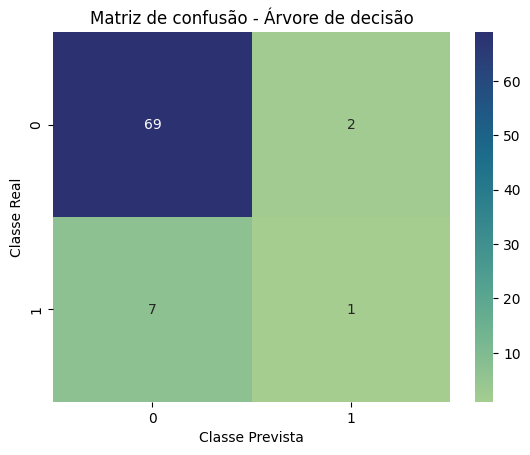

In [5]:
# Matriz de confusão do baseline (Árvore de Decisão)
confusion_m = confusion_matrix(y_test, y_pred_DT)

# Visualização da matriz de confusão
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Árvore de decisão")
plt.show()

In [11]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_DT))

# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_DT)
print("AUC:", auc)

# validação cruzada (k-fold estratificada)
pred_estratificada = cross_val_predict(clf_DT, X, y, cv=sk.model_selection.StratifiedKFold(n_splits=5))
print(classification_report(y, pred_estratificada, digits=4))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        71
           1       0.33      0.12      0.18         8

    accuracy                           0.89        79
   macro avg       0.62      0.55      0.56        79
weighted avg       0.85      0.89      0.86        79

AUC: 0.5484154929577465
              precision    recall  f1-score   support

           0     0.9227    0.9110    0.9168       236
           1     0.2759    0.3077    0.2909        26

    accuracy                         0.8511       262
   macro avg     0.5993    0.6094    0.6039       262
weighted avg     0.8586    0.8511    0.8547       262



## 4) Teste simples de hipoteses:
Nesta secção avaliamos se algumas variáveis estão a representar a mesma informação e se podem ser removidas sem perda relevante de desempenho.

- Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)
- Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

Objetivo: identificar a forma mais simples de representar os dados, reduzindo redundância e mantendo qualidade preditiva.

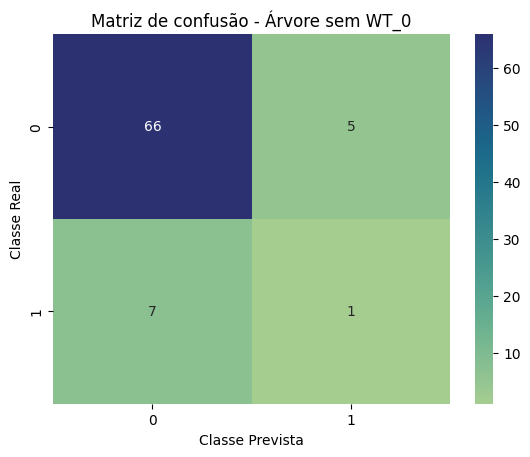

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC sem WT_0: 0.5272887323943662


In [10]:
# Remover WT_0 dos dados de treino e teste
col_wt0 = 'WT_0'

if col_wt0 in X_train.columns and col_wt0 in X_test.columns:
    X_train_sem_wt = X_train.drop(columns=[col_wt0])
    X_test_sem_wt = X_test.drop(columns=[col_wt0])

    # Treinar modelo sem WT_0
    clf_DT_sem_wt = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_sem_wt = clf_DT_sem_wt.fit(X_train_sem_wt, y_train)

    # Previsões
    y_pred_DT_sem_wt = clf_DT_sem_wt.predict(X_test_sem_wt)

    # Matriz de confusão
    confusion_sem_wt = confusion_matrix(y_test, y_pred_DT_sem_wt)
    sns.heatmap(confusion_sem_wt, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore sem WT_0")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_sem_wt))
    auc_sem_wt = roc_auc_score(y_test, y_pred_DT_sem_wt)
    print("AUC sem WT_0:", auc_sem_wt)
else:
    print("WT_0 não foi encontrada em X_train/X_test.")

# 4.1) Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)

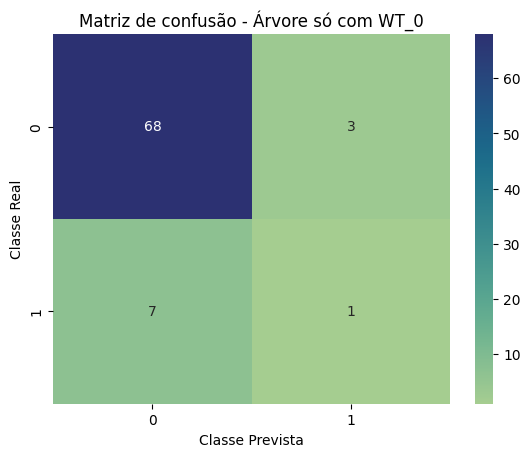

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        71
           1       0.25      0.12      0.17         8

    accuracy                           0.87        79
   macro avg       0.58      0.54      0.55        79
weighted avg       0.84      0.87      0.85        79

AUC só com WT_0: 0.5413732394366197


In [ ]:
# Manter WT_0 e remover os componentes (WD_0, WR_0, WAtotal_0/WATotal)
mapa = {c.lower(): c for c in X_train.columns}

chave_wa = 'watotal_0' if 'watotal_0' in mapa else ('watotal' if 'watotal' in mapa else None)
componentes = []
for chave in ['wd_0', 'wr_0']:
    if chave in mapa:
        componentes.append(mapa[chave])
if chave_wa is not None:
    componentes.append(mapa[chave_wa])

if 'wt_0' in mapa:
    X_train_so_wt = X_train.drop(columns=componentes, errors='ignore')
    X_test_so_wt = X_test.drop(columns=componentes, errors='ignore')

    # Treinar modelo mantendo WT_0
    clf_DT_so_wt = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_so_wt = clf_DT_so_wt.fit(X_train_so_wt, y_train)

    # Previsões
    y_pred_DT_so_wt = clf_DT_so_wt.predict(X_test_so_wt)

    # Matriz de confusão
    confusion_so_wt = confusion_matrix(y_test, y_pred_DT_so_wt)
    sns.heatmap(confusion_so_wt, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore só com WT_0")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_so_wt))
    auc_so_wt = roc_auc_score(y_test, y_pred_DT_so_wt)
    print("AUC só com WT_0:", auc_so_wt)
else:
    print("WT_0 não foi encontrada em X_train/X_test.")

Com base nos resultados obtidos, a comparação entre WT_0 e os seus componentes fica apresentada no mesmo formato do RL_final, permitindo decidir de forma direta qual das duas representações é mais informativa neste contexto.

# 4.2) Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

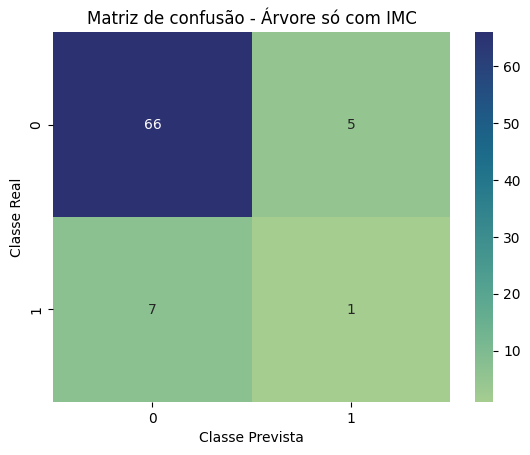

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC só com IMC: 0.5272887323943662


In [55]:
# Manter IMC e remover Peso/Altura_cm
mapa = {c.lower(): c for c in X_train.columns}

col_imc = mapa.get('imc')
col_peso = mapa.get('peso')
col_altura = mapa.get('altura_cm')

if col_imc is not None:
    remover = [c for c in [col_peso, col_altura] if c is not None]
    X_train_so_imc = X_train.drop(columns=remover, errors='ignore')
    X_test_so_imc = X_test.drop(columns=remover, errors='ignore')

    # Treinar modelo mantendo IMC
    clf_DT_so_imc = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_so_imc = clf_DT_so_imc.fit(X_train_so_imc, y_train)

    # Previsões
    y_pred_DT_so_imc = clf_DT_so_imc.predict(X_test_so_imc)

    # Matriz de confusão
    confusion_so_imc = confusion_matrix(y_test, y_pred_DT_so_imc)
    sns.heatmap(confusion_so_imc, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore só com IMC")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_so_imc))
    auc_so_imc = roc_auc_score(y_test, y_pred_DT_so_imc)
    print("AUC só com IMC:", auc_so_imc)
else:
    print("IMC não foi encontrada em X_train/X_test.")

## 8) Teste simples só com Peso e Altura (sem IMC)

Neste bloco removemos IMC dos dados de treino e teste, mantendo Peso e Altura_cm.

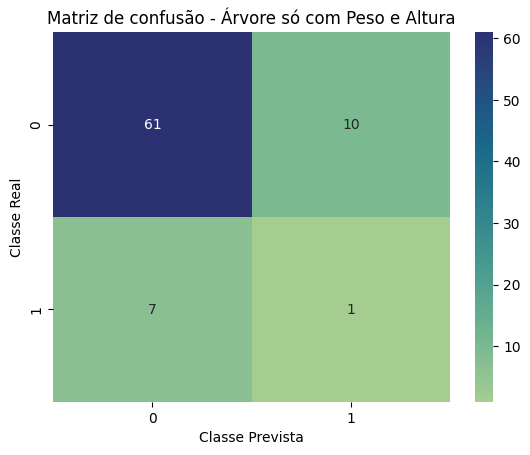

              precision    recall  f1-score   support

           0       0.90      0.86      0.88        71
           1       0.09      0.12      0.11         8

    accuracy                           0.78        79
   macro avg       0.49      0.49      0.49        79
weighted avg       0.82      0.78      0.80        79

AUC só com Peso e Altura: 0.4920774647887324


In [56]:
# Manter Peso/Altura_cm e remover IMC
mapa = {c.lower(): c for c in X_train.columns}

col_imc = mapa.get('imc')
col_peso = mapa.get('peso')
col_altura = mapa.get('altura_cm')

if col_peso is not None and col_altura is not None:
    X_train_so_peso_altura = X_train.drop(columns=[col_imc] if col_imc is not None else [], errors='ignore')
    X_test_so_peso_altura = X_test.drop(columns=[col_imc] if col_imc is not None else [], errors='ignore')

    # Treinar modelo mantendo Peso e Altura
    clf_DT_so_peso_altura = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_so_peso_altura = clf_DT_so_peso_altura.fit(X_train_so_peso_altura, y_train)

    # Previsões
    y_pred_DT_so_peso_altura = clf_DT_so_peso_altura.predict(X_test_so_peso_altura)

    # Matriz de confusão
    confusion_so_peso_altura = confusion_matrix(y_test, y_pred_DT_so_peso_altura)
    sns.heatmap(confusion_so_peso_altura, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore só com Peso e Altura")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_so_peso_altura))
    auc_so_peso_altura = roc_auc_score(y_test, y_pred_DT_so_peso_altura)
    print("AUC só com Peso e Altura:", auc_so_peso_altura)
else:
    print("Peso/Altura_cm não foram encontradas em X_train/X_test.")

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1) Árvore com peso para a classe minoritária
clf_dt_bal = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# 2) Treinar no treino
clf_dt_bal.fit(X_train, y_train)

# 3) Previsões no teste
y_pred_bal = clf_dt_bal.predict(X_test)
y_proba_bal = clf_dt_bal.predict_proba(X_test)[:, 1]

print("=== TESTE ===")
print(classification_report(y_test, y_pred_bal, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_bal))
print("AUC:", roc_auc_score(y_test, y_proba_bal))

# 4) Validação cruzada estratificada para estimar generalização
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pred_cv_bal = cross_val_predict(clf_dt_bal, X, y, cv=cv)
proba_cv_bal = cross_val_predict(clf_dt_bal, X, y, cv=cv, method="predict_proba")[:, 1]

print("\n=== CROSS-VALIDATION ===")
print(classification_report(y, pred_cv_bal, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y, pred_cv_bal))
print("AUC:", roc_auc_score(y, proba_cv_bal))

=== TESTE ===
              precision    recall  f1-score   support

           0     0.9054    0.9437    0.9241        71
           1     0.2000    0.1250    0.1538         8

    accuracy                         0.8608        79
   macro avg     0.5527    0.5343    0.5390        79
weighted avg     0.8340    0.8608    0.8461        79

Matriz de confusão:
 [[67  4]
 [ 7  1]]
AUC: 0.5343309859154929

=== CROSS-VALIDATION ===
              precision    recall  f1-score   support

           0     0.9129    0.9322    0.9224       236
           1     0.2381    0.1923    0.2128        26

    accuracy                         0.8588       262
   macro avg     0.5755    0.5623    0.5676       262
weighted avg     0.8459    0.8588    0.8520       262

Matriz de confusão:
 [[220  16]
 [ 21   5]]
AUC: 0.5622555410691004


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1) Algumas versões mais regularizadas da árvore
configs = {
    "dt_rasa": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=3
    ),
    "dt_folha_5": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=5
    ),
    "dt_rasa_folha_5": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=3,
        min_samples_leaf=5
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in configs.items():
    print(f"\n\n===== {nome} =====")
    
    # treino no conjunto de treino
    modelo.fit(X_train, y_train)
    
    # teste
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    print("\n--- TESTE ---")
    print(classification_report(y_test, y_pred, digits=4))
    print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_proba))
    
    # validação cruzada
    pred_cv = cross_val_predict(modelo, X, y, cv=cv)
    proba_cv = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba")[:, 1]
    
    print("\n--- CROSS-VALIDATION ---")
    print(classification_report(y, pred_cv, digits=4))
    print("Matriz de confusão:\n", confusion_matrix(y, pred_cv))
    print("AUC:", roc_auc_score(y, proba_cv))



===== dt_rasa =====

--- TESTE ---
              precision    recall  f1-score   support

           0     0.9434    0.7042    0.8065        71
           1     0.1923    0.6250    0.2941         8

    accuracy                         0.6962        79
   macro avg     0.5679    0.6646    0.5503        79
weighted avg     0.8673    0.6962    0.7546        79

Matriz de confusão:
 [[50 21]
 [ 3  5]]
AUC: 0.6628521126760564

--- CROSS-VALIDATION ---
              precision    recall  f1-score   support

           0     0.9140    0.7203    0.8057       236
           1     0.1316    0.3846    0.1961        26

    accuracy                         0.6870       262
   macro avg     0.5228    0.5525    0.5009       262
weighted avg     0.8363    0.6870    0.7452       262

Matriz de confusão:
 [[170  66]
 [ 16  10]]
AUC: 0.5317796610169492


===== dt_folha_5 =====

--- TESTE ---
              precision    recall  f1-score   support

           0     0.9153    0.7606    0.8308        71
  

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Garantir que o modelo escolhido está treinado
clf_dt_rasa = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=3
)

clf_dt_rasa.fit(X_train, y_train)

# Probabilidades da classe positiva
y_proba_test = clf_dt_rasa.predict_proba(X_test)[:, 1]

# Thresholds a testar
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for thr in thresholds:
    y_pred_thr = (y_proba_test >= thr).astype(int)
    
    print(f"\n===== THRESHOLD = {thr} =====")
    print(classification_report(y_test, y_pred_thr, digits=4))
    print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_thr))
    print("AUC:", roc_auc_score(y_test, y_proba_test))


===== THRESHOLD = 0.3 =====
              precision    recall  f1-score   support

           0     0.9434    0.7042    0.8065        71
           1     0.1923    0.6250    0.2941         8

    accuracy                         0.6962        79
   macro avg     0.5679    0.6646    0.5503        79
weighted avg     0.8673    0.6962    0.7546        79

Matriz de confusão:
 [[50 21]
 [ 3  5]]
AUC: 0.6628521126760564

===== THRESHOLD = 0.4 =====
              precision    recall  f1-score   support

           0     0.9434    0.7042    0.8065        71
           1     0.1923    0.6250    0.2941         8

    accuracy                         0.6962        79
   macro avg     0.5679    0.6646    0.5503        79
weighted avg     0.8673    0.6962    0.7546        79

Matriz de confusão:
 [[50 21]
 [ 3  5]]
AUC: 0.6628521126760564

===== THRESHOLD = 0.5 =====
              precision    recall  f1-score   support

           0     0.9434    0.7042    0.8065        71
           1     0.192

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1) Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2) Modelo base
dt = DecisionTreeClassifier(random_state=42)

# 3) Grelha de hiperparâmetros
param_grid = {
    "class_weight": [None, "balanced"],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# 4) Grid search
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="recall",   # foco em apanhar positivos
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid.best_params_)
print("Melhor recall médio CV:", grid.best_score_)

# 5) Melhor modelo
best_dt = grid.best_estimator_

# 6) Avaliação no teste
y_pred_best = best_dt.predict(X_test)
y_proba_best = best_dt.predict_proba(X_test)[:, 1]

print("\n=== TESTE | threshold=0.5 ===")
print(classification_report(y_test, y_pred_best, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_best))
print("AUC:", roc_auc_score(y_test, y_proba_best))

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Melhores parâmetros:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor recall médio CV: 0.5666666666666667

=== TESTE | threshold=0.5 ===
              precision    recall  f1-score   support

           0     0.9583    0.6479    0.7731        71
           1     0.1935    0.7500    0.3077         8

    accuracy                         0.6582        79
   macro avg     0.5759    0.6989    0.5404        79
weighted avg     0.8809    0.6582    0.7260        79

Matriz de confusão:
 [[46 25]
 [ 2  6]]
AUC: 0.7411971830985915


In [28]:
# Probabilidades do melhor modelo
y_proba_best = best_dt.predict_proba(X_test)[:, 1]

# Threshold 0.6
thr = 0.73
y_pred_thr = (y_proba_best >= thr).astype(int)

print("=== TESTE | threshold=0.6 ===")
print(classification_report(y_test, y_pred_thr, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_thr))
print("AUC:", roc_auc_score(y_test, y_proba_best))

=== TESTE | threshold=0.6 ===
              precision    recall  f1-score   support

           0     0.9286    0.9155    0.9220        71
           1     0.3333    0.3750    0.3529         8

    accuracy                         0.8608        79
   macro avg     0.6310    0.6452    0.6375        79
weighted avg     0.8683    0.8608    0.8644        79

Matriz de confusão:
 [[65  6]
 [ 5  3]]
AUC: 0.7411971830985915
